### Uniform Exploration

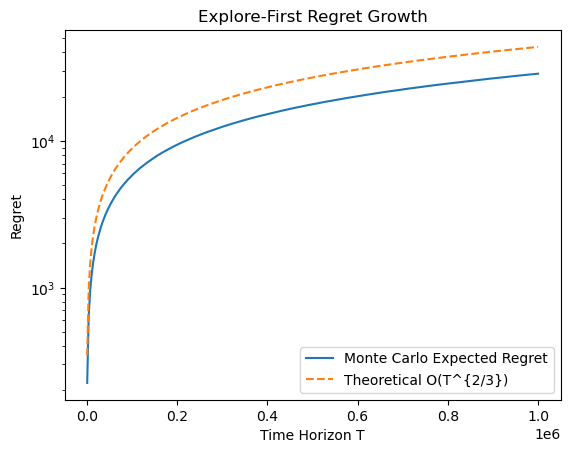

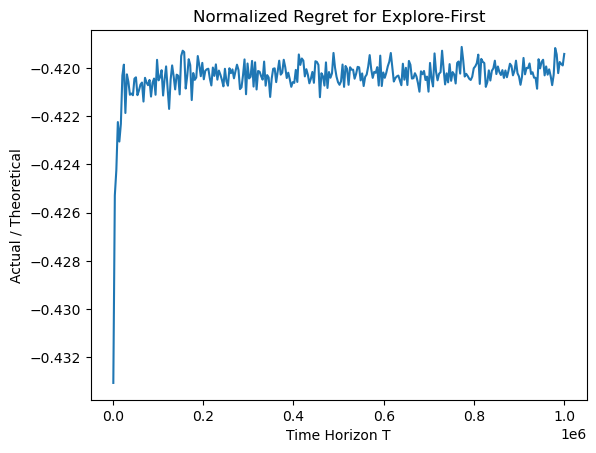

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

def explore_first(mu, N, T):
    K = len(mu)
    rewards = []
    estimates = []
    for a in range(K):
        rewards_a = np.random.binomial(1, mu[a], N)
        rewards.extend(rewards_a)
        estimates.append(np.mean(rewards_a))
    #print(rewards)
    #print(estimates)
    
    best_arm = np.argmax(estimates)
    #print(best_arm)
    
    remaining = T - K * N
    if remaining > 0:
        rewards_a = np.random.binomial(1, mu[best_arm], remaining)
        rewards.extend(rewards_a)
    
    mu_star = max(mu)
    
    regret = mu_star * T - np.sum(rewards)
    return regret
    
mu = [0.1, 0.11, 0.9, 0.12, 0.13, 0.098]
N = 20

# def expected_regret(mu, T, runs=1000):
#     K = len(mu)
#     N = int((T/K)**(2/3) * (np.log(T))**(1/3))
    
#     regrets = []
    
#     for _ in range(runs):
#         regrets.append(explore_first(mu, N, T))
        
#     return np.mean(regrets)


def expected_regret(mu, T, runs=1000):
    K = len(mu)
    mu_arr = np.array(mu)
    N = max(1, int((T / K) ** (2/3) * (np.log(max(T, 2))) ** (1/3)))

    # All exploration rewards at once: shape (runs, K, N)
    exploration = np.random.binomial(1, mu_arr[None, :, None], (runs, K, N))
    estimates = exploration.mean(axis=2)           # (runs, K)
    best_arms = np.argmax(estimates, axis=1)       # (runs,)
    best_mu = mu_arr[best_arms]                    # (runs,)

    remaining = max(T - K * N, 0)
    # Sum of `remaining` Bernoulli trials = one Binomial draw per run
    exploitation = np.random.binomial(remaining, best_mu)  # (runs,)

    total_rewards = exploration.sum(axis=(1, 2)) + exploitation
    return np.mean(max(mu) * T - total_rewards)

time_horizons = np.linspace(1000, 1_000_000, 300, dtype=int)
monte_carlo_expected_regret = [expected_regret(mu, T) for T in time_horizons]

theoretical_expected_regret = (time_horizons ** (2/3)) * ((len(mu) * np.log(time_horizons)) ** (1/3))

plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")

plt.yscale("log")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")

plt.legend()
plt.title("Explore-First Regret Growth")
plt.show()

normalized_regret = np.array(monte_carlo_expected_regret) / theoretical_expected_regret
plt.plot(time_horizons, np.log(normalized_regret))
plt.xlabel("Time Horizon T")
plt.ylabel("Actual / Theoretical")
plt.title("Normalized Regret for Explore-First")
plt.show()









# time_horizons = np.arange(1, 1000001, 1000)
# monte_carlo_expected_regret = []
# C = 0.2 

# for th in time_horizons:
#     monte_carlo_expected_regret.append(expected_regret(mu, th))
    
# theoretical_expected_regret = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


# plt.plot(time_horizons, monte_carlo_expected_regret, label="Monte Carlo Expected Regret")
# plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical O(T^{2/3})", linestyle="--")

# plt.xlabel("Time Horizon T")
# plt.ylabel("Regret")
# plt.legend()
# plt.title("Explore-First Regret Growth")

# plt.show()

# normalized_regret = np.array(monte_carlo_expected_regret) / theoretical_expected_regret

# plt.plot(time_horizons, normalized_regret)
# plt.xlabel("Time Horizon T")
# plt.ylabel("Actual / Theoretical")
# plt.title("Normalized Regret for Explore-First")
# plt.show()

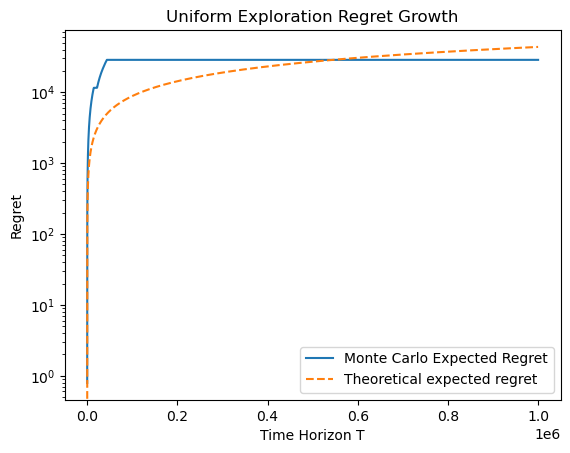

/tmp/ipykernel_1903/1067991191.py:77: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve_uniform / theoretical_expected_regret


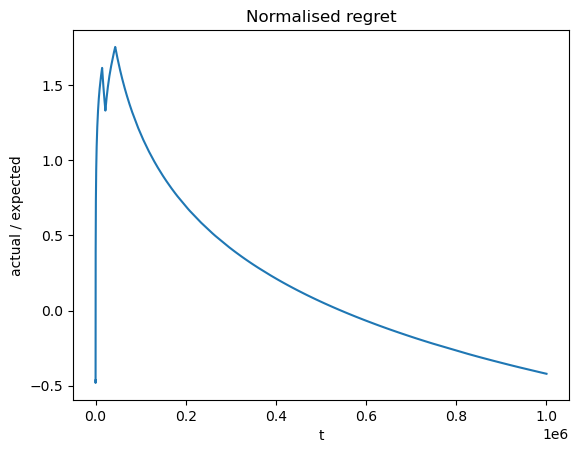

In [2]:
from numba import njit

import numpy as np
from numba import njit

@njit
def uniform_exploration_curve(mu, T, N):
    
    K = len(mu)
    estimates = np.zeros(K)
    counts = np.zeros(K)

    rewards = np.zeros(T)

    t = 0

    # exploration phase
    for a in range(K):
        for _ in range(N):
            reward = np.random.binomial(1, mu[a])
            rewards[t] = reward
            counts[a] += 1
            estimates[a] += (reward - estimates[a]) / counts[a]
            t += 1

    best_arm = np.argmax(estimates)

    # exploitation phase
    while t < T:
        reward = np.random.binomial(1, mu[best_arm])
        rewards[t] = reward
        t += 1

    return rewards


def expected_regret_curve_uniform(mu, T, runs=200):
    
    K = len(mu)
    best_mu = np.max(mu)

    all_curves = np.zeros((runs, T))

    N = max(1, int((T / K) ** (2/3) * (np.log(max(T, 2))) ** (1/3)))

    for r in range(runs):

        rewards = uniform_exploration_curve(mu, T, N)
        cum_rewards = np.cumsum(rewards)

        all_curves[r] = best_mu * np.arange(1, T + 1) - cum_rewards

    return all_curves.mean(axis=0)

#N = 20
T = 1000000
#C = 0.2 

time_horizons = np.arange(1, T + 1)
    
expected_curve_uniform = expected_regret_curve_uniform(mu, T, runs=1000)
theoretical_expected_regret = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, expected_curve_uniform, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical expected regret", linestyle="--")

plt.yscale("log")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Uniform Exploration Regret Growth")

plt.show()

normalised = expected_curve_uniform / theoretical_expected_regret
plt.plot(time_horizons, np.log(normalised))
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()


### Epsilon Greedy

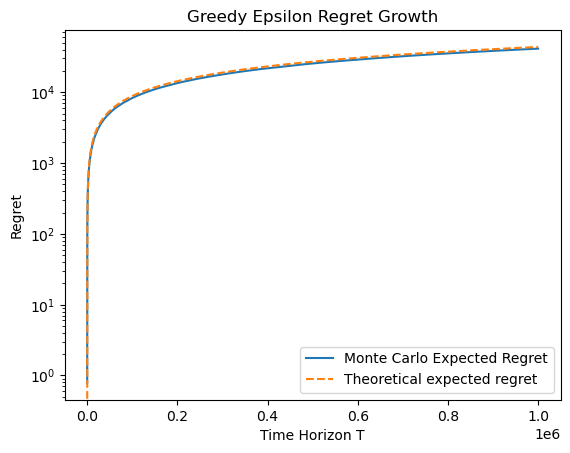

/tmp/ipykernel_1903/1300473951.py:64: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve_eg / theoretical_expected_regret


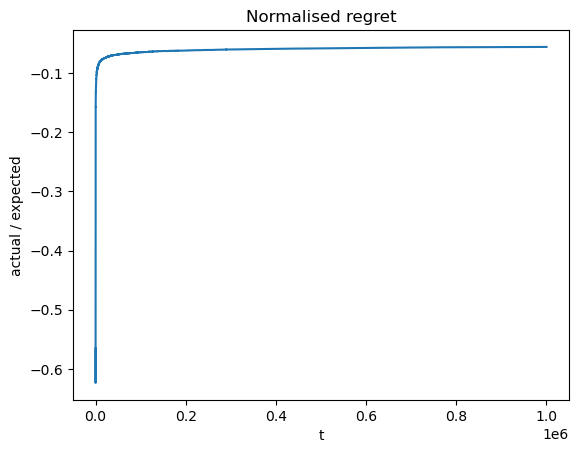

In [3]:
from numba import njit

@njit
def epsilon_greedy(mu, T):
    
    K = len(mu) # K is no. of arms
    estimates = np.zeros(K)
    counts = np.zeros(K)
    rewards = []
    
    for t in range(1, T + 1):  # t starts from 1 to avoid log(0)
        # epsilon_t = t^{-1/3} * (K log t)^{1/3}
        epsilon_t = (t ** (-1/3)) * ((K * np.log(t)) ** (1/3))
        
        # explore vs exploit
        if np.random.rand() < epsilon_t:
            action = np.random.randint(K)  # explore
        else:
            action = np.argmax(estimates)  # exploit
            
        reward = np.random.binomial(n=1, p=mu[action])
        
        counts[action] += 1
        
        estimates[action] += (reward - estimates[action]) / counts[action]
        
        rewards.append(reward)
    
    return rewards

def expected_regret_curve_eg(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)
    
    for _ in range(runs):
        rewards = epsilon_greedy(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))
    
    cumulative_regret /= runs  # average over runs
    return cumulative_regret

#N = 20
T = 1000000
#C = 0.2 

time_horizons = np.arange(1, T + 1)
    
expected_curve_eg = expected_regret_curve_eg(mu, T, runs=1000)
theoretical_expected_regret = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))


plt.plot(time_horizons, expected_curve_eg, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical_expected_regret, label="Theoretical expected regret", linestyle="--")

plt.yscale("log")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Greedy Epsilon Regret Growth")

plt.show()

normalised = expected_curve_eg / theoretical_expected_regret
plt.plot(time_horizons, np.log(normalised))
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()


### Sucessive Elimination

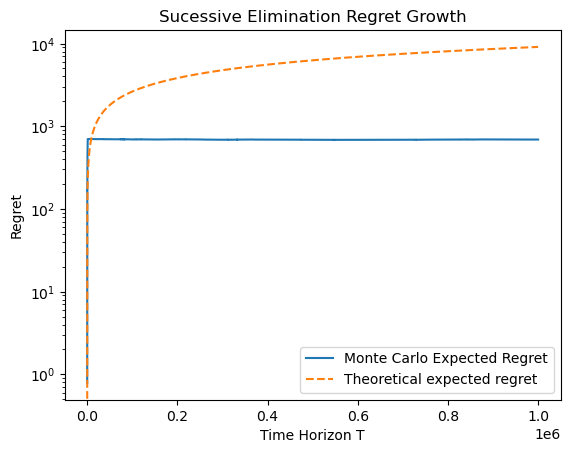

/tmp/ipykernel_1903/1249040932.py:85: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve_se / theoretical


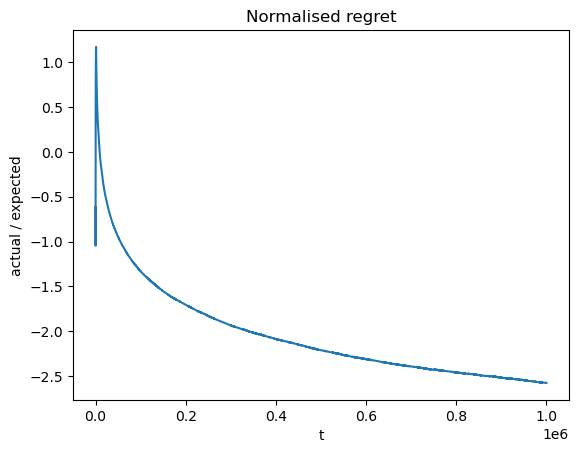

In [4]:
@njit
def successive_elimination(mu, T):
    K = len(mu)
    t = 0
    active = set(range(K))
    counts = np.zeros(K)
    estimates = np.zeros(K)
    rewards = []
    
    while t < T:
        for a in list(active):
            if t >= T:
                break
            reward = np.random.binomial(n=1, p=mu[a])
            counts[a] += 1
            estimates[a] += (reward - estimates[a]) / counts[a]
            
            rewards.append(reward)
            t += 1
            
        UCB = np.zeros(K)
        LCB = np.zeros(K)
        
        for a in active:
            radius = math.sqrt(2 * np.log(T) / counts[a])
            UCB[a] = estimates[a] + radius
            LCB[a] = estimates[a] - radius
            
        # elimination
        new_active = set()
        
        for a in active:
            eliminate = False
            for b in active:
                if a != b and UCB[a] < LCB[b]:
                    eliminate = True
                    break
            if not eliminate:
                new_active.add(a)
        
        active = new_active
        
        if len(active) == 1:
            best_arm = list(active)[0]
            while t < T:
                reward = np.random.binomial(n=1, p=mu[best_arm])
                rewards.append(reward)
                t += 1
            break
    return rewards

def expected_regret_curve_se(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)
    
    for _ in range(runs):
        rewards = successive_elimination(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))
    
    cumulative_regret /= runs  # average over runs
    return cumulative_regret

#N = 20
T = 1000000
#C = 0.2 
K = len(mu)

time_horizons = np.arange(1, T + 1)
    
expected_curve_se = expected_regret_curve_se(mu, T, runs=1000)
theoretical = np.sqrt(K * time_horizons * np.log(time_horizons))


plt.plot(time_horizons, expected_curve_se, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical, label="Theoretical expected regret", linestyle="--")

plt.yscale("log")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Sucessive Elimination Regret Growth")
plt.show()

normalised = expected_curve_se / theoretical
plt.plot(time_horizons, np.log(normalised))
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()

### Optimism under uncertainty

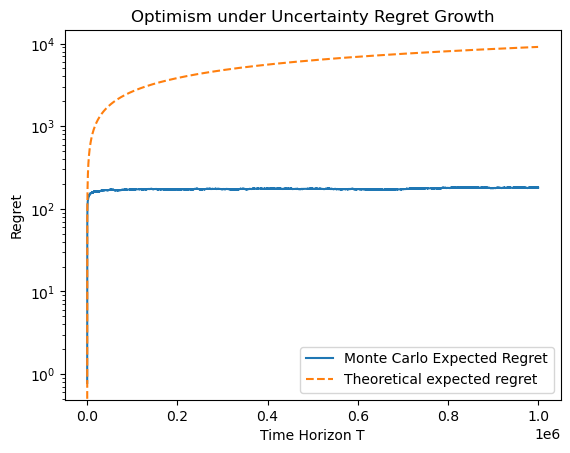

/tmp/ipykernel_1903/3637845196.py:60: RuntimeWarning: divide by zero encountered in divide
  normalised = expected_curve_ucb / theoretical


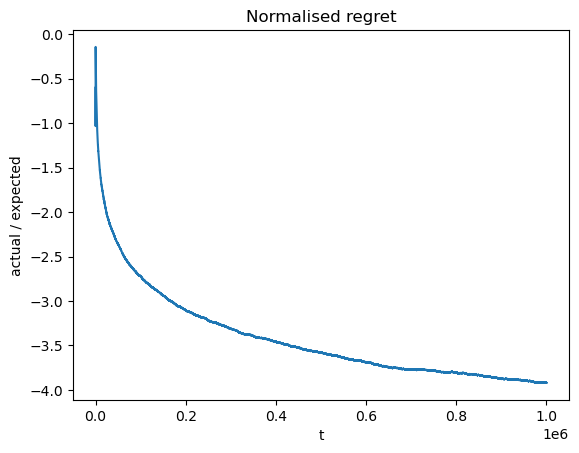

In [5]:
@njit
def ucb1(mu, T):
    K = len(mu)
    estimates = np.zeros(K)
    counts = np.zeros(K)
    cumulative_regret = np.zeros(T)
    optimal = max(mu)
    rewards = []
    
    for a in range(K):
        reward = np.random.binomial(1, mu[a])
        counts[a] = 1
        estimates[a] = reward
        rewards.append(reward)
    
    for t in range(K + 1, T + 1):
        ucb = estimates + np.sqrt(2 * np.log(T) / counts)
        action = np.argmax(ucb)

        reward = np.random.binomial(1, mu[action])
        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]
        rewards.append(reward)

    return rewards

def expected_regret_curve_ucb(mu, T, runs=200):
    optimal_reward = max(mu)
    cumulative_regret = np.zeros(T)

    for _ in range(runs):
        rewards = ucb1(mu, T)
        cumulative_regret += np.cumsum(optimal_reward - np.array(rewards))

    cumulative_regret /= runs
    return cumulative_regret
    
#N = 20
T = 1000000
#C = 0.2 
K = len(mu)

time_horizons = np.arange(1, T + 1)
    
expected_curve_ucb = expected_regret_curve_ucb(mu, T, runs=1000)
theoretical = np.sqrt(K * time_horizons * np.log(time_horizons))


plt.plot(time_horizons, expected_curve_ucb, label="Monte Carlo Expected Regret")
plt.plot(time_horizons, theoretical, label="Theoretical expected regret", linestyle="--")

plt.yscale("log")

plt.xlabel("Time Horizon T")
plt.ylabel("Regret")
plt.legend()
plt.title("Optimism under Uncertainty Regret Growth")
plt.show()

normalised = expected_curve_ucb / theoretical
plt.plot(time_horizons, np.log(normalised))
plt.xlabel("t")
plt.ylabel("actual / expected")
plt.title("Normalised regret")
plt.show()


    

### Intial Findings

if normalised val $< 1$ then our actual performance is better than the expected theoretical bound. Otherwise, if it is $> 1$ then our actual performance is worse than the expected theorectical bound. The closer to $1$ the normalised val is the better the convergence

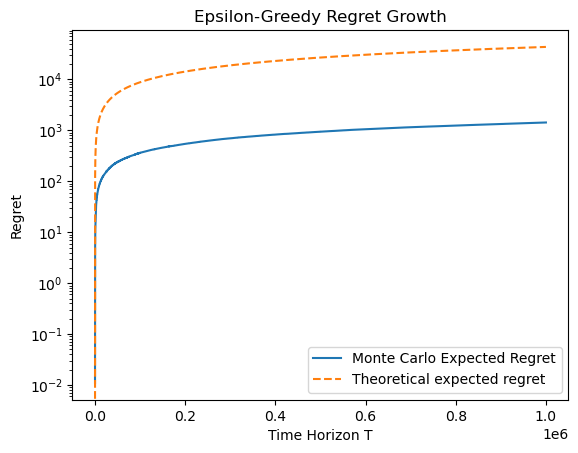

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


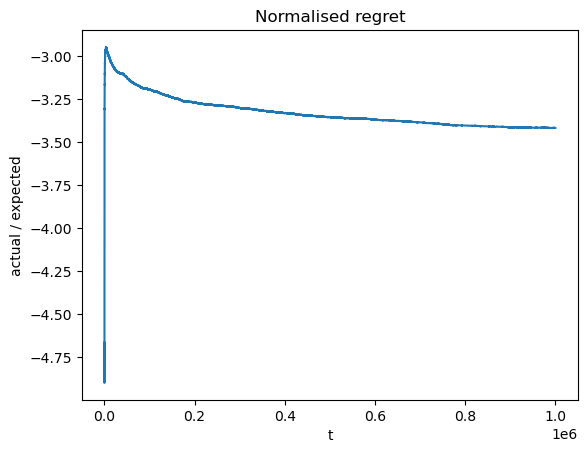

In [6]:
def plot_regret_analysis(
    mu,
    curve,
    theoretical_fn,
    T_max=1_000_000,
    title_prefix="Algorithm"
):
    K = len(mu)
    t = np.arange(1, T_max + 1)
    theoretical = theoretical_fn(K, t)

    plt.plot(t, curve, label="Monte Carlo Expected Regret")
    plt.plot(t, theoretical, label="Theoretical expected regret", linestyle="--")
    
    plt.yscale("log")
    
    plt.xlabel("Time Horizon T")
    plt.ylabel("Regret")
    plt.legend()
    plt.title(f"{title_prefix} Regret Growth")
    plt.show()

    plt.plot(t, np.log(curve / theoretical))
    
    plt.xlabel("t")
    plt.ylabel("actual / expected")
    plt.title("Normalised regret")
    plt.show()
mu_similar = [0.1, 0.11, 0.099, 0.12, 0.13, 0.098]
T = 1000000
expected_curve_eg_similar = expected_regret_curve_eg(mu_similar, T, 1000)
theoretical_expected_regret_eg_similar = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))

# usage
plot_regret_analysis(
    mu_similar,
    curve=expected_curve_eg_similar,
    theoretical_fn=lambda K, t: (t**(2/3)) * ((K * np.log(t))**(1/3)),
    T_max=T,
    title_prefix="Epsilon-Greedy"
)





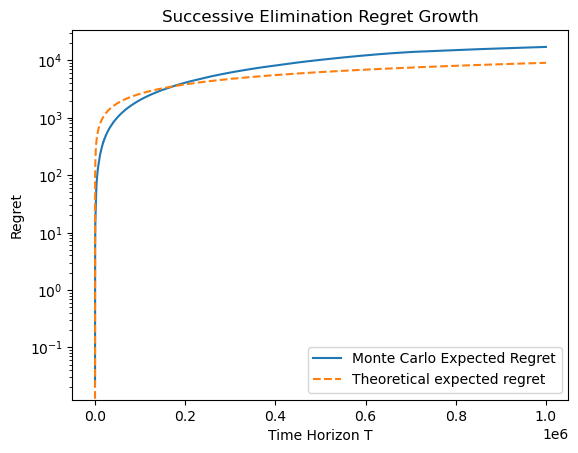

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


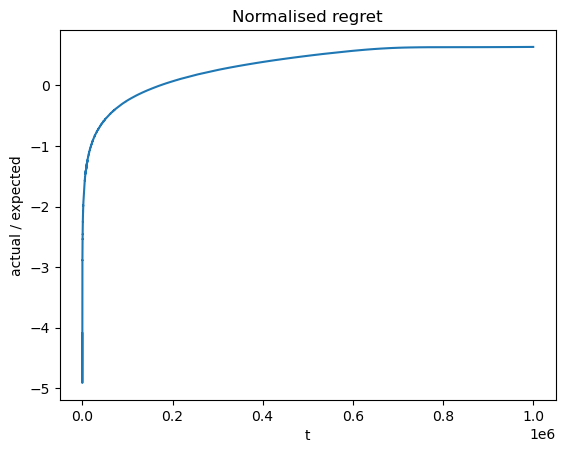

In [7]:
expected_curve_se_similar = expected_regret_curve_se(mu_similar, T, 1000)
theoretical_expected_regret_se_similar = np.sqrt(K * time_horizons * np.log(time_horizons))

plot_regret_analysis(
    mu_similar,
    curve=expected_curve_se_similar,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="Successive Elimination"
)

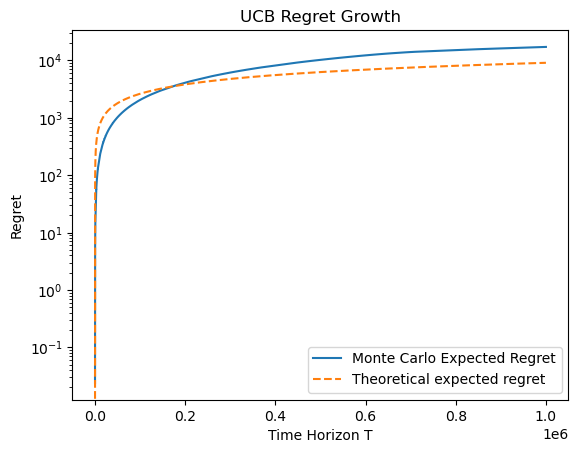

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


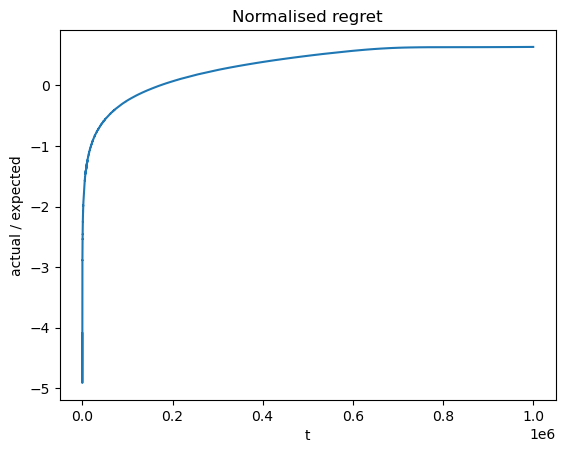

In [8]:
expected_curve_ucb_similar = expected_regret_curve_ucb(mu_similar, T, 1000)
theoretical_expected_regret_ucb_similar = np.sqrt(K * time_horizons * np.log(time_horizons))

plot_regret_analysis(
    mu_similar,
    curve=expected_curve_se_similar,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="UCB"
)

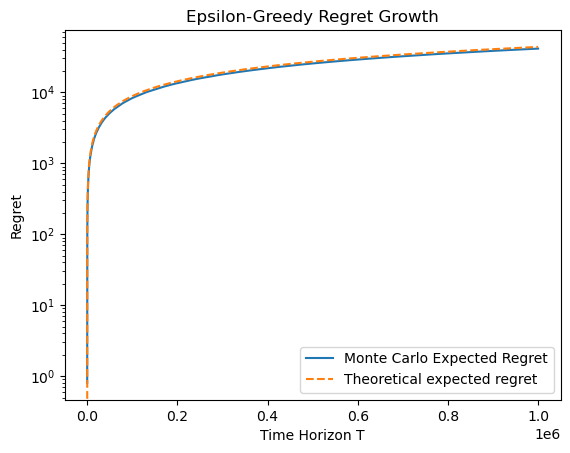

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


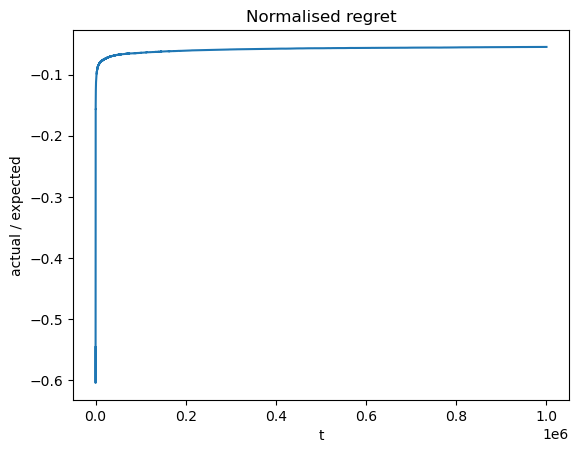

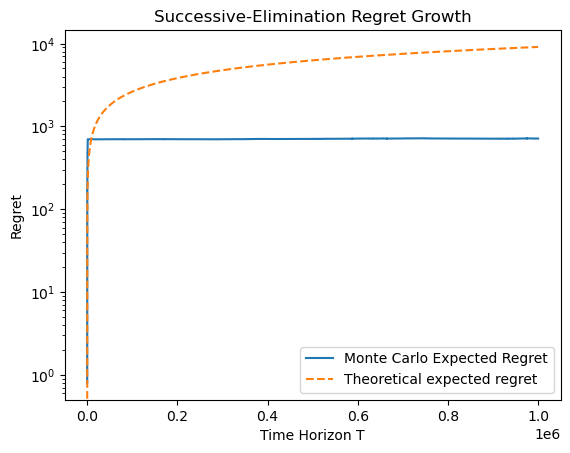

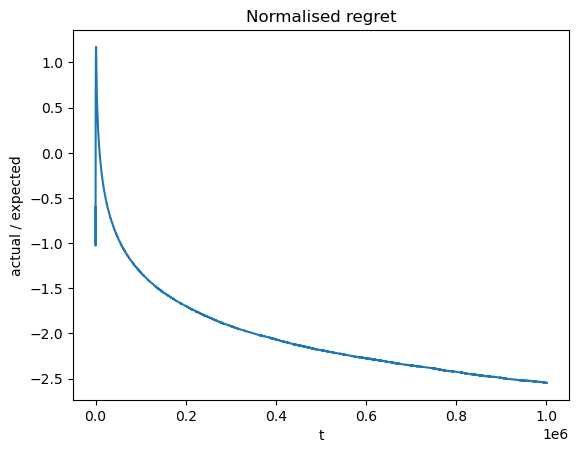

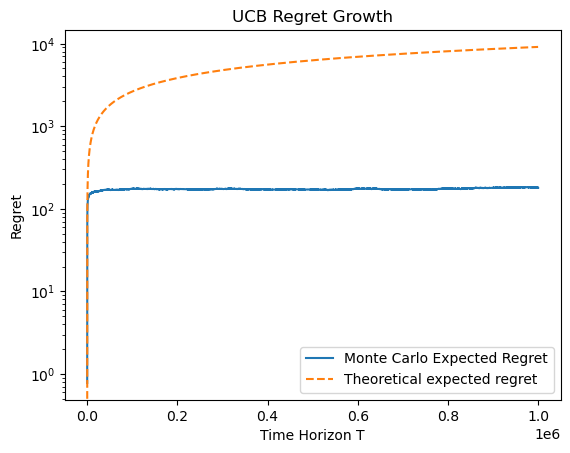

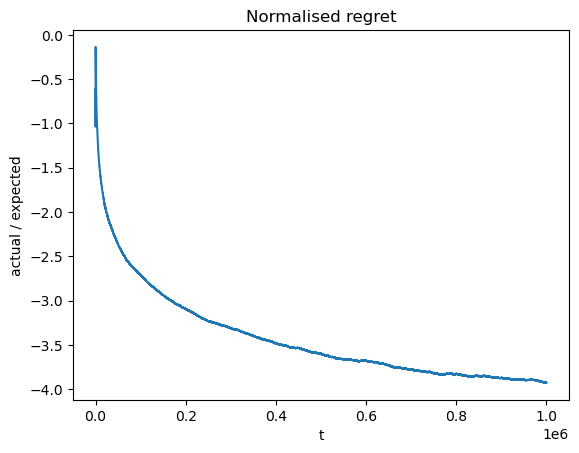

In [9]:
mu_one_winner =  [0.1, 0.11, 0.9, 0.12, 0.13, 0.098]
expected_curve_eg_one_winner = expected_regret_curve_eg(mu_one_winner, T, 1000)
expected_curve_ucb_one_winner = expected_regret_curve_ucb(mu_one_winner, T, 1000)
expected_curve_se_one_winner = expected_regret_curve_se(mu_one_winner, T, 1000)



plot_regret_analysis(
    mu_one_winner,
    curve=expected_curve_eg_one_winner,
    theoretical_fn=lambda K, t: (t**(2/3)) * ((K * np.log(t))**(1/3)),
    T_max=T,
    title_prefix="Epsilon-Greedy"
)


plot_regret_analysis(
    mu_one_winner,
    curve=expected_curve_se_one_winner,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="Successive-Elimination"
)


plot_regret_analysis(
    mu_one_winner,
    curve=expected_curve_ucb_one_winner,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="UCB"
)


## Note

UCB and Successive-Elimination exploit the gap between the best arm and the rest aggressively so the converge to the best arm very quickly and hence the simulated regret being much lower than the expected regret - they perform much better on instances where the mean of one arm is significantly greater than the rest.

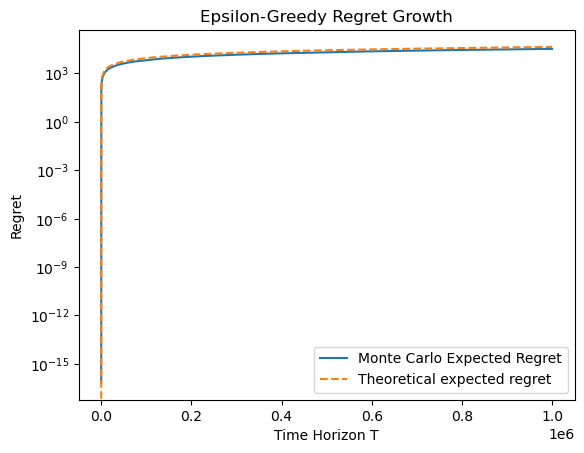

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


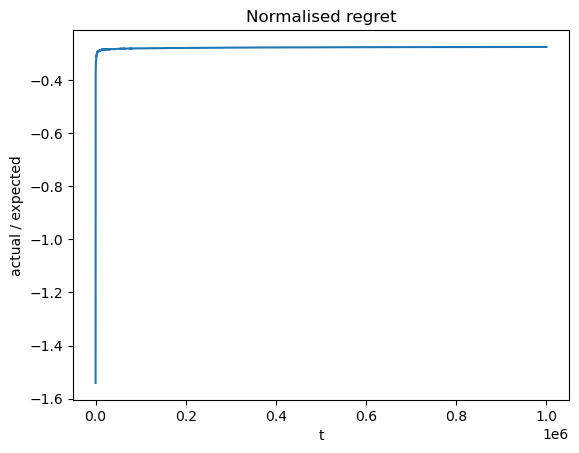

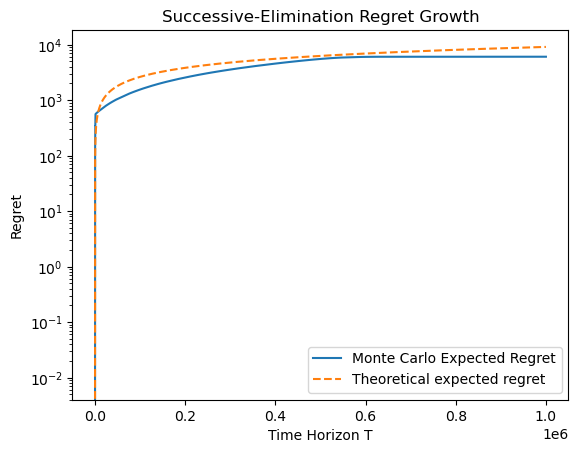

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: invalid value encountered in log
  plt.plot(t, np.log(curve / theoretical))


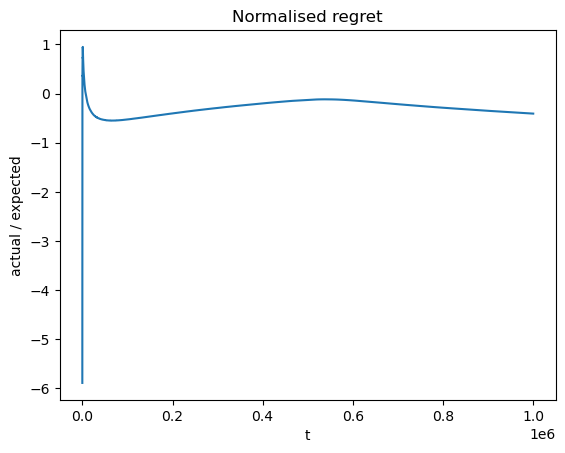

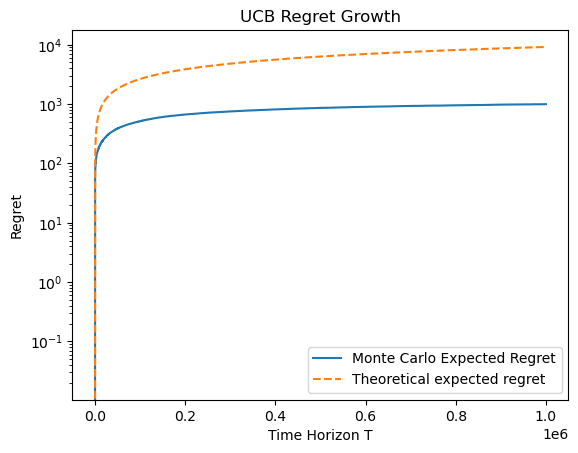

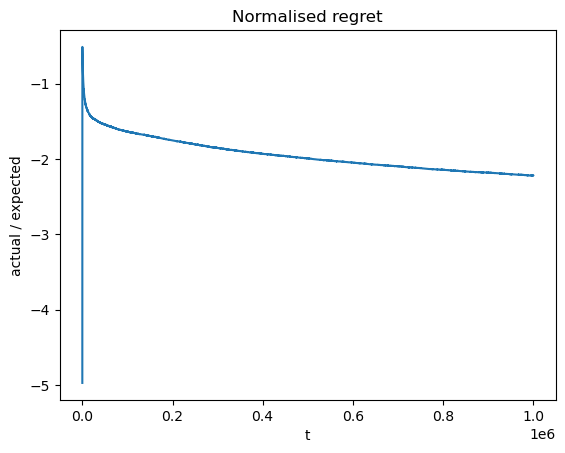

In [10]:
mu_two_winners = [0.9, 0.88, 0.1, 0.12, 0.13, 0.11]
expected_curve_eg_two_winners = expected_regret_curve_eg(mu_two_winners, T, 1000)
expected_curve_ucb_two_winners = expected_regret_curve_ucb(mu_two_winners, T, 1000)
expected_curve_se_two_winners = expected_regret_curve_se(mu_two_winners, T, 1000)



plot_regret_analysis(
    mu_two_winners,
    curve=expected_curve_eg_two_winners,
    theoretical_fn=lambda K, t: (t**(2/3)) * ((K * np.log(t))**(1/3)),
    T_max=T,
    title_prefix="Epsilon-Greedy"
)


plot_regret_analysis(
    mu_two_winners,
    curve=expected_curve_se_two_winners,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="Successive-Elimination"
)


plot_regret_analysis(
    mu_two_winners,
    curve=expected_curve_ucb_two_winners,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="UCB"
)

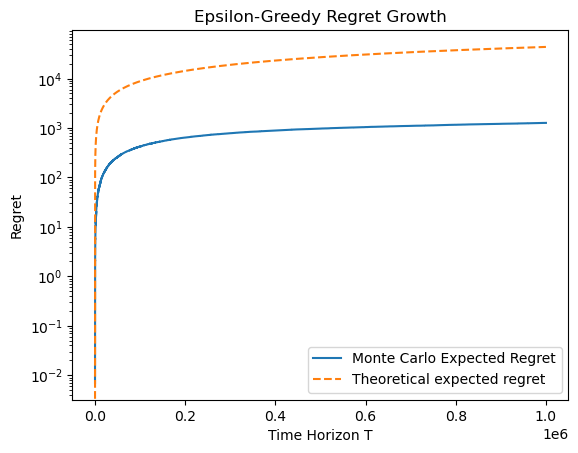

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


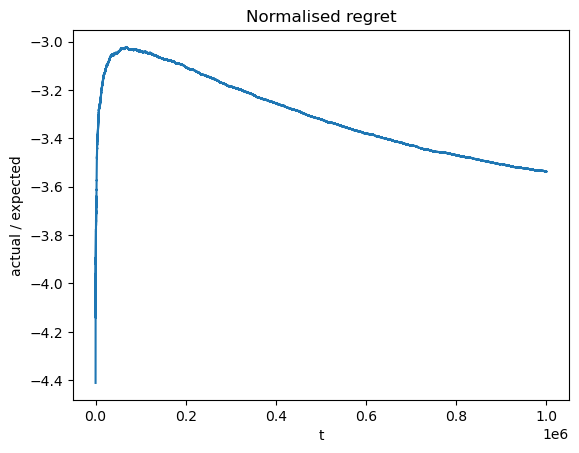

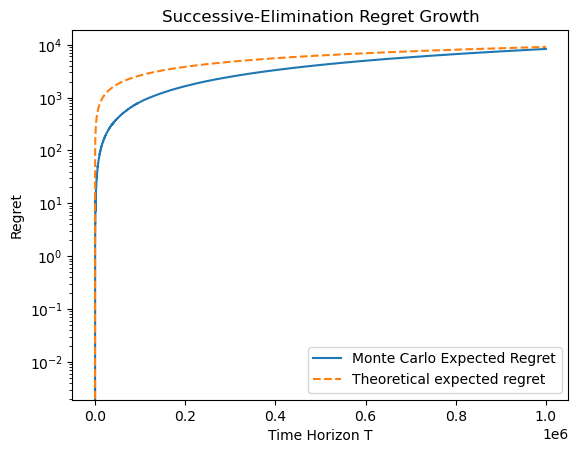

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: invalid value encountered in log
  plt.plot(t, np.log(curve / theoretical))


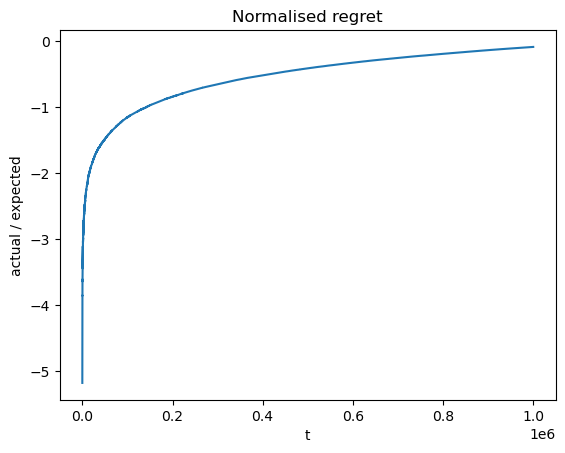

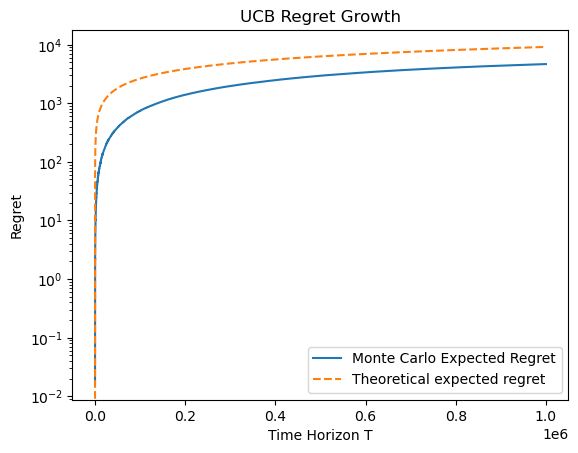

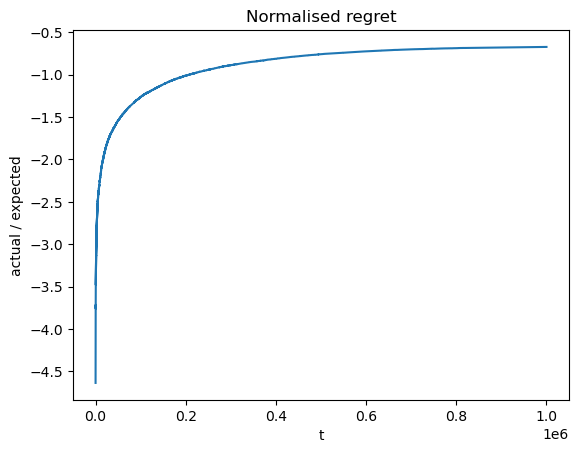

In [11]:
mu_one_slightly_better = [0.5, 0.51, 0.5, 0.5, 0.5, 0.5]
expected_curve_eg_slightly_better = expected_regret_curve_eg(mu_one_slightly_better, T, 1000)
expected_curve_ucb_slightly_better = expected_regret_curve_ucb(mu_one_slightly_better, T, 1000)
expected_curve_se_slightly_better = expected_regret_curve_se(mu_one_slightly_better, T, 1000)



plot_regret_analysis(
    mu_one_slightly_better,
    curve=expected_curve_eg_slightly_better,
    theoretical_fn=lambda K, t: (t**(2/3)) * ((K * np.log(t))**(1/3)),
    T_max=T,
    title_prefix="Epsilon-Greedy"
)


plot_regret_analysis(
    mu_one_slightly_better,
    curve=expected_curve_se_slightly_better,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="Successive-Elimination"
)


plot_regret_analysis(
    mu_one_slightly_better,
    curve=expected_curve_ucb_slightly_better,
    theoretical_fn=lambda K, t: np.sqrt(K * t * np.log(t)),
    T_max=T,
    title_prefix="UCB"
)

### Thompson Sampling

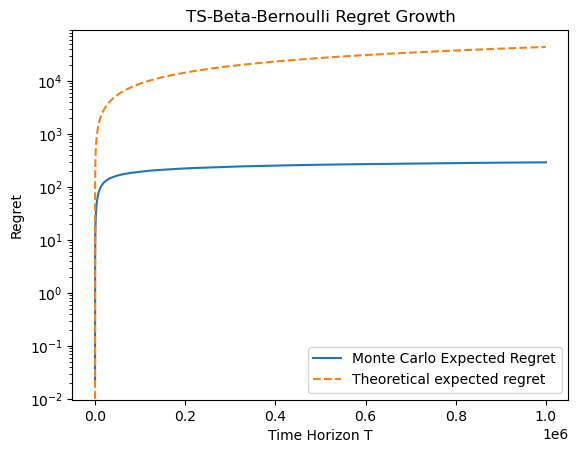

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


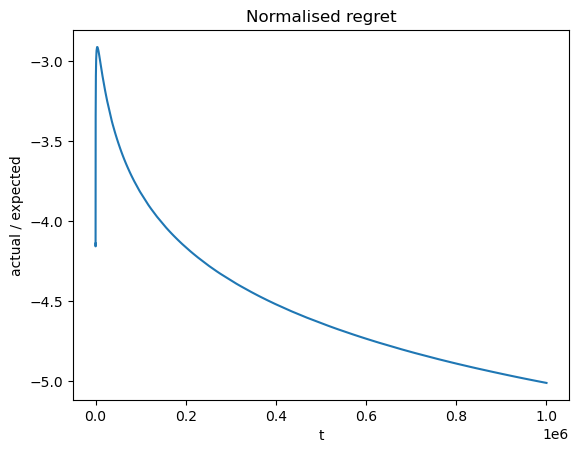

In [12]:
from numba import njit, prange
import numpy as np

@njit(parallel=True)
def expected_regret_curve_ts_beta_bernoulli_fast(mu, T, runs=200):
    K = len(mu)
    best_mean = np.max(mu)
    all_regrets = np.zeros((runs, T))  # now T points, not T//stride

    for r in prange(runs):
        alpha = np.ones(K)
        beta_param = np.ones(K)
        cum_reg = 0.0

        for t in range(T):
            samples = np.empty(K)
            for a in range(K):
                samples[a] = np.random.beta(alpha[a], beta_param[a])

            a_t = np.argmax(samples)
            r_t = np.random.binomial(1, mu[a_t])
            cum_reg += best_mean - mu[a_t]

            alpha[a_t] += r_t
            beta_param[a_t] += 1 - r_t

            all_regrets[r, t] = cum_reg  # store every step

    result = np.zeros(T)
    for r in range(runs):
        for i in range(T):
            result[i] += all_regrets[r, i]
    return result / runs

# --- run ---
T = 1_000_000
mu_similar = np.array([0.1, 0.11, 0.099, 0.12, 0.13, 0.098])

curve_full = expected_regret_curve_ts_beta_bernoulli_fast(mu_similar, T, runs=1000)

plot_regret_analysis(
    mu_similar,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Beta-Bernoulli"
)

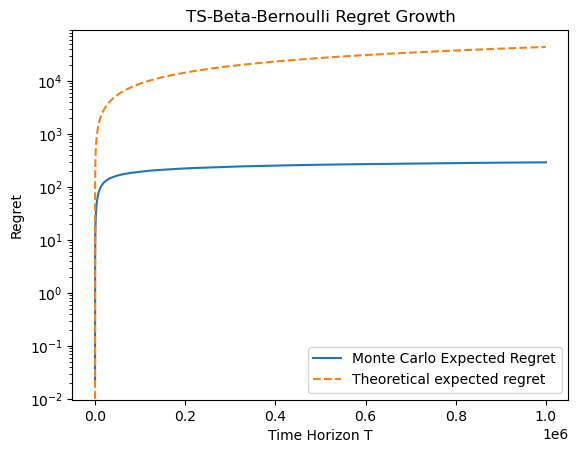

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


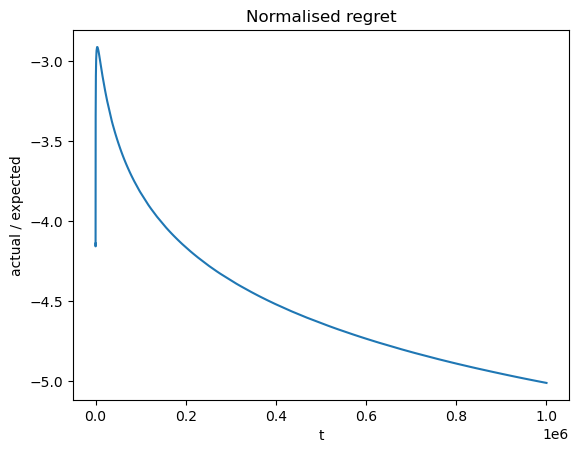

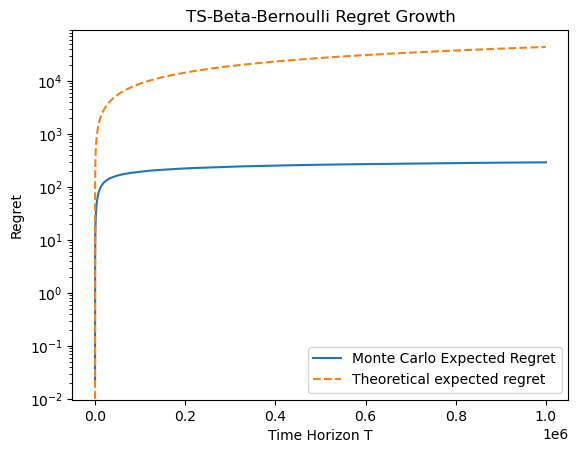

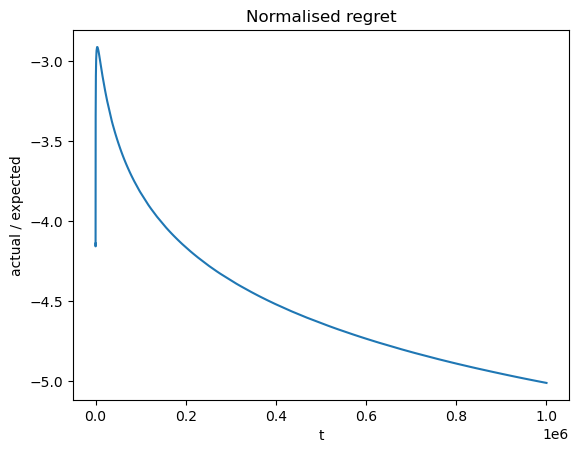

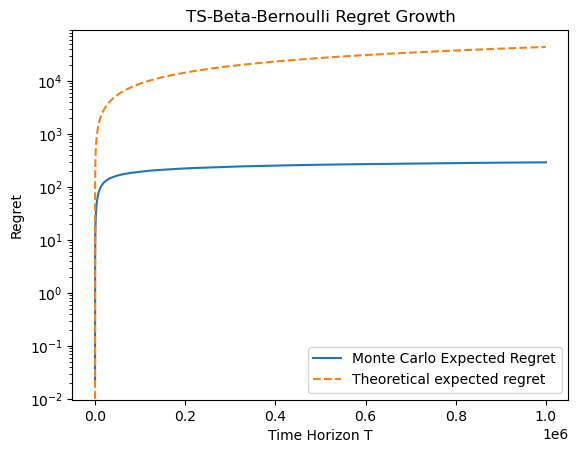

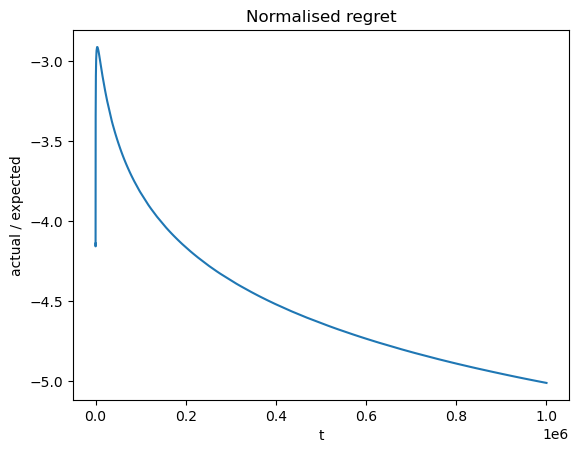

In [13]:
mu_one_winner  = np.array([0.1, 0.11, 0.9, 0.12, 0.13, 0.098])

expected_curve_mu_one_winner_ts_bb = expected_regret_curve_ts_beta_bernoulli_fast(mu_one_winner, T, runs=1000)

plot_regret_analysis(
    mu_one_winner,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Beta-Bernoulli"
)

mu_two_winners  = np.array([0.9, 0.88, 0.1, 0.12, 0.13, 0.11])

expected_curve_mu_two_winners_ts_bb = expected_regret_curve_ts_beta_bernoulli_fast(mu_two_winners, T, runs=1000)

plot_regret_analysis(
    mu_two_winners,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Beta-Bernoulli"
)

mu_one_slightly_better = np.array([0.5, 0.51, 0.5, 0.5, 0.5, 0.5])

expected_curve_mu_one_slightly_better_ts_bb = expected_regret_curve_ts_beta_bernoulli_fast(mu_one_slightly_better, T, runs=1000)

plot_regret_analysis(
    mu_one_slightly_better,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Beta-Bernoulli"
)

In [14]:
# gaussian conjugate
@njit(parallel=True)
def expected_regret_curve_ts_gaussian_fast(mu, sigma, T, runs=200, stride=100,
                                            mu0=0.5, sigma0=1.0):
    """
    mu     : true mean rewards per arm
    sigma  : known noise std of reward likelihood (same for all arms)
    mu0    : prior mean (same for all arms)
    sigma0 : prior std  (same for all arms)
    """
    K = len(mu)
    best_mean = np.max(mu)
    n_points = T // stride
    all_regrets = np.zeros((runs, n_points))

    sigma2  = sigma  ** 2   # likelihood variance
    sigma02 = sigma0 ** 2   # prior variance

    for r in prange(runs):
        # sufficient statistics per arm
        sum_rewards = np.zeros(K)   # REW_H
        counts      = np.zeros(K)   # t per arm

        cum_reg = 0.0

        for t in range(T):
            samples = np.empty(K)

            for a in range(K):
                # posterior variance and mean (from doc formulas)
                post_var  = 1.0 / (1.0 / sigma02 + counts[a] / sigma2)
                post_mean = post_var * (mu0 / sigma02 + sum_rewards[a] / sigma2)
                samples[a] = np.random.normal(post_mean, np.sqrt(post_var))

            a_t = np.argmax(samples)

            # Gaussian reward
            r_t = np.random.normal(mu[a_t], sigma)

            cum_reg += best_mean - mu[a_t]

            sum_rewards[a_t] += r_t
            counts[a_t]      += 1.0

            if (t + 1) % stride == 0:
                all_regrets[r, (t + 1) // stride - 1] = cum_reg

    result = np.zeros(n_points)
    for r in range(runs):
        for i in range(n_points):
            result[i] += all_regrets[r, i]
    return result / runs

# --- run ---
T = 1000000
stride = 100
sigma  = 1.0   # known noise std

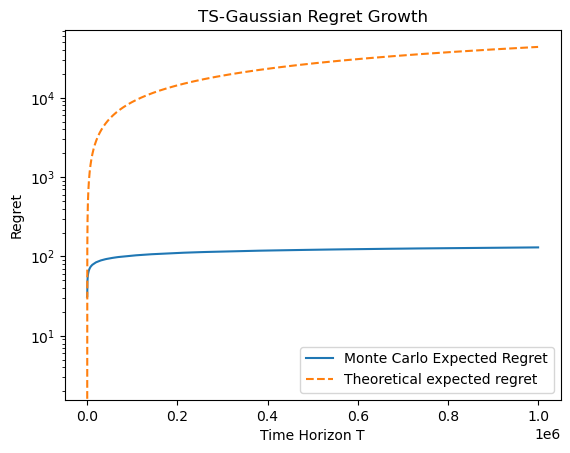

/tmp/ipykernel_1903/3115512546.py:23: RuntimeWarning: divide by zero encountered in divide
  plt.plot(t, np.log(curve / theoretical))


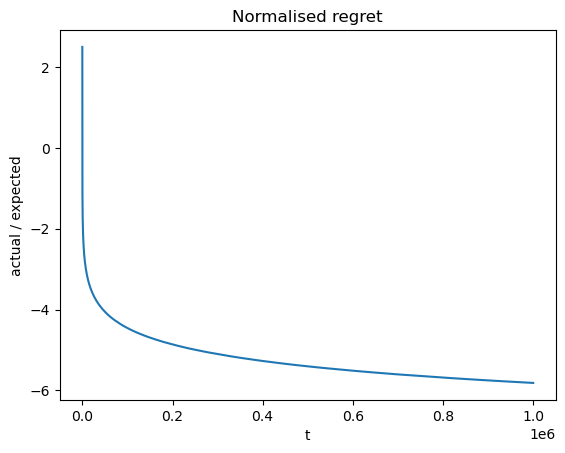

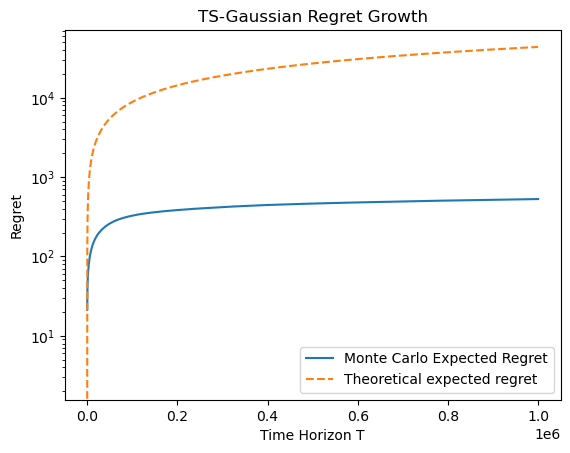

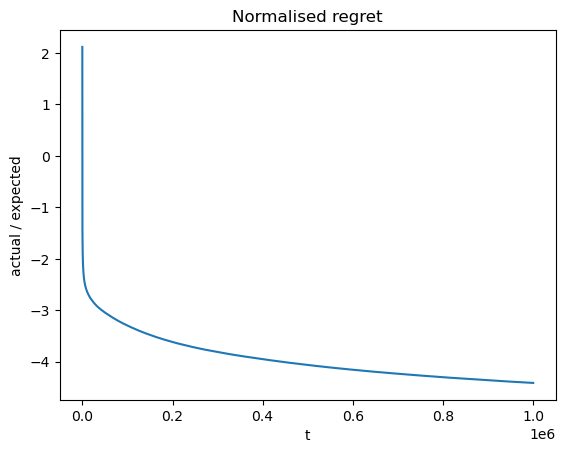

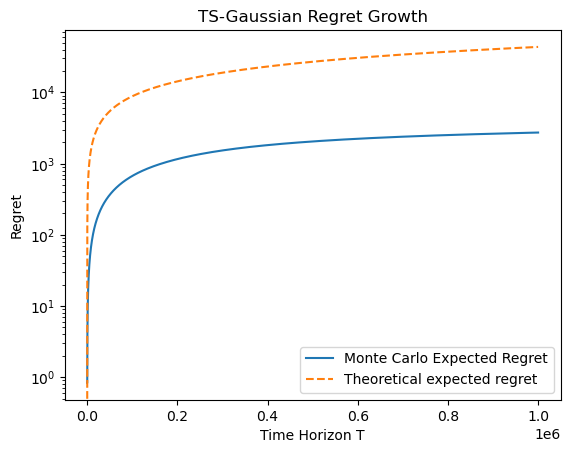

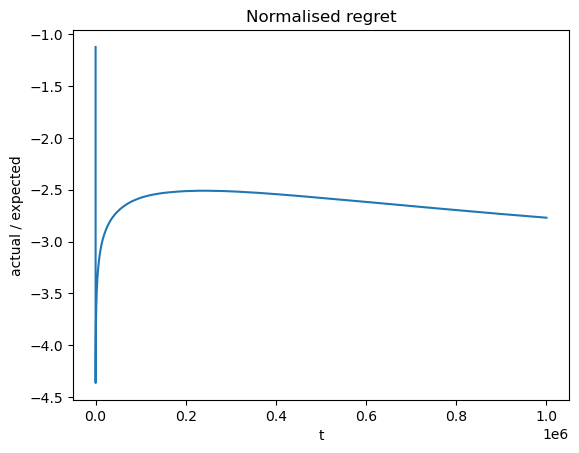

In [15]:
mu_one_winner  = np.array([0.1, 0.11, 0.9, 0.12, 0.13, 0.098])

expected_curve_mu_one_winner_ts_g = expected_regret_curve_ts_gaussian_fast(mu_one_winner, sigma, T, runs=1000, stride=stride)
t_axis = np.arange(stride, T + 1, stride)
curve_full = np.interp(np.arange(1, T + 1), t_axis, expected_curve_mu_one_winner_ts_g)

plot_regret_analysis(
    mu_one_winner,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Gaussian"
)

mu_two_winners  = np.array([0.9, 0.88, 0.1, 0.12, 0.13, 0.11])

expected_curve_mu_two_winners_ts_g = expected_regret_curve_ts_gaussian_fast(mu_two_winners, sigma, T, runs=1000, stride=stride)
t_axis = np.arange(stride, T + 1, stride)
curve_full = np.interp(np.arange(1, T + 1), t_axis, expected_curve_mu_two_winners_ts_g)

plot_regret_analysis(
    mu_two_winners,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Gaussian"
)

mu_one_slightly_better = np.array([0.5, 0.51, 0.5, 0.5, 0.5, 0.5])

expected_curve_mu_one_slightly_better_ts_g = expected_regret_curve_ts_gaussian_fast(mu_one_slightly_better, sigma, T, runs=1000, stride=stride)
t_axis = np.arange(stride, T + 1, stride)
curve_full = np.interp(np.arange(1, T + 1), t_axis, expected_curve_mu_one_slightly_better_ts_g)

plot_regret_analysis(
    mu_one_slightly_better,
    curve=curve_full,
    theoretical_fn=lambda K, t: (t ** (2 / 3)) * ((K * np.log(t)) ** (1 / 3)),
    T_max=T,
    title_prefix="TS-Gaussian"
)

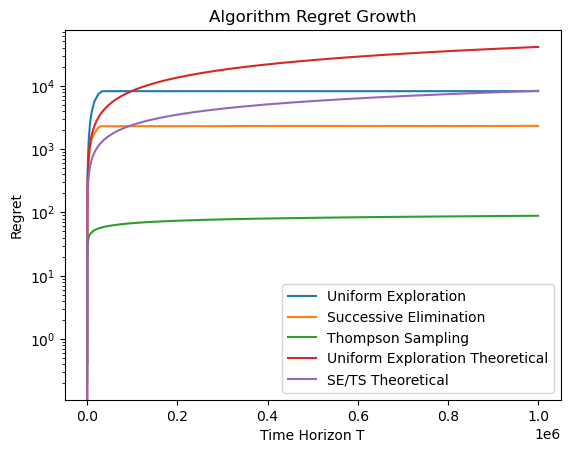

In [16]:
mu = [0.1, 0.2, 0.3, 0.4, 0.5]

def plot_regret_for_three(mu, T_max=1_000_000, title_prefix="Algorithm"):
    mu = np.array(mu) 
    K = len(mu)
    T = T_max
    time_horizons = np.arange(1, T_max + 1)
    regret_curve_uniform_exploration = expected_regret_curve_uniform(mu, T, runs=1000)
    regret_curve_successive_elimination = expected_regret_curve_se(mu, T, runs=1000)
    regret_curve_thompson_sampling_beta_bernoulli = expected_regret_curve_ts_beta_bernoulli_fast(mu, T, runs=1000)
    theoretical_expected_regret_uniform_exp = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))
    theoretical_log_bound = np.sqrt(K * time_horizons * np.log(time_horizons))
    best = np.log(time_horizons)
    
    plt.plot(time_horizons, regret_curve_uniform_exploration,
             label="Uniform Exploration")

    plt.plot(time_horizons, regret_curve_successive_elimination,
             label="Successive Elimination")

    plt.plot(time_horizons, regret_curve_thompson_sampling_beta_bernoulli,
             label="Thompson Sampling")

    plt.plot(time_horizons, theoretical_expected_regret_uniform_exp, label="Uniform Exploration Theoretical")
    
    plt.plot(time_horizons, theoretical_log_bound, label="SE/TS Theoretical")


    plt.yscale("log")
    
    plt.xlabel("Time Horizon T")
    plt.ylabel("Regret")
    plt.legend()
    plt.title(f"{title_prefix} Regret Growth")
    plt.show()
    

# usage
plot_regret_for_three(mu)





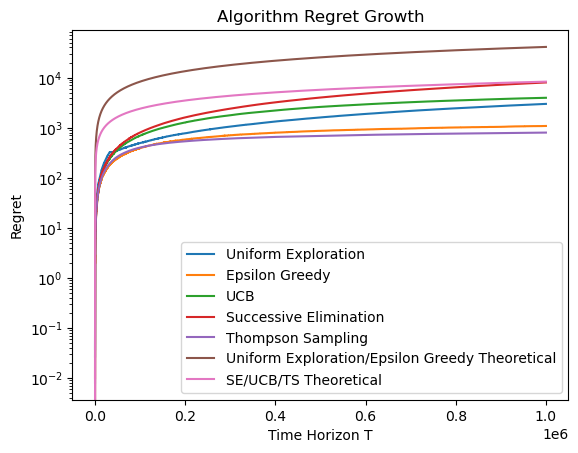

In [18]:
mu = [0.5, 0.5, 0.5, 0.5, 0.51]

def plot_regret_for_three(mu, T_max=1_000_000, title_prefix="Algorithm"):
    mu = np.array(mu) 
    K = len(mu)
    T = T_max
    time_horizons = np.arange(1, T_max + 1)
    regret_curve_uniform_exploration = expected_regret_curve_uniform(mu, T, runs=1000)
    regret_curve_epislon_greedy = expected_regret_curve_eg(mu, T, runs=1000)
    regret_curve_successive_elimination = expected_regret_curve_se(mu, T, runs=1000)
    regret_curve_ucb = expected_regret_curve_ucb(mu, T, runs=1000)
    regret_curve_thompson_sampling_beta_bernoulli = expected_regret_curve_ts_beta_bernoulli_fast(mu, T, runs=1000)
    theoretical_expected_regret_uniform_exp = (time_horizons**(2/3))*((len(mu)*np.log(time_horizons))**(1/3))
    theoretical_log_bound = np.sqrt(K * time_horizons * np.log(time_horizons))
    best = np.log(time_horizons)
    
    plt.plot(time_horizons, regret_curve_uniform_exploration,
             label="Uniform Exploration")
    
    plt.plot(time_horizons, regret_curve_epislon_greedy,
             label="Epsilon Greedy")
    
    plt.plot(time_horizons, regret_curve_ucb,
             label="UCB")

    plt.plot(time_horizons, regret_curve_successive_elimination,
             label="Successive Elimination")

    plt.plot(time_horizons, regret_curve_thompson_sampling_beta_bernoulli,
             label="Thompson Sampling")

    plt.plot(time_horizons, theoretical_expected_regret_uniform_exp, label="Uniform Exploration/Epsilon Greedy Theoretical")
    
    plt.plot(time_horizons, theoretical_log_bound, label="SE/UCB/TS Theoretical")


    plt.yscale("log")
    
    plt.xlabel("Time Horizon T")
    plt.ylabel("Regret")
    plt.legend()
    plt.title(f"{title_prefix} Regret Growth")
    plt.show()
    

# usage
plot_regret_for_three(mu)



